In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
customers = pd.read_csv("olist_customers_dataset.csv")

In [16]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [17]:
customers.shape


(99441, 5)

In [18]:
customers.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='str')

In [19]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


In [20]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [21]:
orders = pd.read_csv("olist_orders_dataset.csv")

payments = pd.read_csv("olist_order_payments_dataset.csv")

items = pd.read_csv("olist_order_items_dataset.csv")

products = pd.read_csv("olist_products_dataset.csv")

In [22]:
print("Customers:", customers.shape)

print("Orders:", orders.shape)

print("Payments:", payments.shape)

print("Items:", items.shape)

print("Products:", products.shape)

Customers: (99441, 5)
Orders: (99441, 8)
Payments: (103886, 5)
Items: (112650, 7)
Products: (32951, 9)


In [23]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [24]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [25]:
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [26]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [27]:
print("Customers")
print(customers.isnull().sum())

print("\nOrders")
print(orders.isnull().sum())

print("\nPayments")
print(payments.isnull().sum())

print("\nItems")
print(items.isnull().sum())

print("\nProducts")
print(products.isnull().sum())

Customers
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Orders
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Payments
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Items
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Products
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_

In [28]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='str')

In [29]:
payments.columns

Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='str')

In [30]:
items.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='str')

In [31]:
products.columns

Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='str')

In [32]:
df = orders.merge(
    payments,
    on='order_id',
    how='left'
)

In [33]:
df.shape

(103887, 12)

In [34]:
df = df.merge(
    customers,
    on='customer_id',
    how='left'
)

In [35]:
df.shape

(103887, 16)

In [36]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,credit_card,1.0,18.12,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,3.0,voucher,1.0,2.00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2.0,voucher,1.0,18.59,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,boleto,1.0,141.46,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,credit_card,3.0,179.12,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO


In [37]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'payment_sequential', 'payment_type', 'payment_installments',
       'payment_value', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='str')

In [38]:
df['payment_value'].sum()

np.float64(16008872.12)

In [39]:
df.shape

(103887, 16)

In [40]:
df = orders.merge(
    payments,
    on='order_id',
    how='left'
)

In [41]:
df = df.merge(
    customers,
    on='customer_id',
    how='left'
)

In [42]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'payment_sequential', 'payment_type', 'payment_installments',
       'payment_value', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='str')

In [43]:
df = df.merge(
    customers,
    on='customer_id',
    how='left'
)

In [44]:
df = df.drop(columns=[
    'customer_unique_id_y',
    'customer_zip_code_prefix_y',
    'customer_city_y',
    'customer_state_y'
])

df = df.rename(columns={
    'customer_unique_id_x': 'customer_unique_id',
    'customer_zip_code_prefix_x': 'customer_zip_code_prefix',
    'customer_city_x': 'customer_city',
    'customer_state_x': 'customer_state'
})

In [45]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'payment_sequential', 'payment_type', 'payment_installments',
       'payment_value', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='str')

In [46]:
df.columns.duplicated()

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False])

In [47]:
sum(df.columns.duplicated())

np.int64(0)

In [48]:
df = df.loc[:, ~df.columns.duplicated()]

In [49]:
df.shape

(103887, 16)

In [50]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'payment_sequential', 'payment_type', 'payment_installments',
       'payment_value', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='str')

In [51]:
df['order_purchase_timestamp'] = pd.to_datetime(
    df['order_purchase_timestamp']
)

In [52]:
df['Month'] = df['order_purchase_timestamp'].dt.to_period('M')

In [53]:
df[['order_purchase_timestamp','Month']].head()

,order_purchase_timestamp,Month
0,2017-10-02 10:56:33,2017-10
1,2017-10-02 10:56:33,2017-10
2,2017-10-02 10:56:33,2017-10
3,2018-07-24 20:41:37,2018-07
4,2018-08-08 08:38:49,2018-08


In [54]:
monthly_sales = df.groupby('Month')['payment_value'].sum()

monthly_sales

Month
2016-09        252.24
2016-10      59090.48
2016-12         19.62
2017-01     138488.04
2017-02     291908.01
2017-03     449863.60
2017-04     417788.03
2017-05     592918.82
2017-06     511276.38
2017-07     592382.92
2017-08     674396.32
2017-09     727762.45
2017-10     779677.88
2017-11    1194882.80
2017-12     878401.48
2018-01    1115004.18
2018-02     992463.34
2018-03    1159652.12
2018-04    1160785.48
2018-05    1153982.15
2018-06    1023880.50
2018-07    1066540.75
2018-08    1022425.32
2018-09       4439.54
2018-10        589.67
Freq: M, Name: payment_value, dtype: float64

In [55]:
monthly_sales.sort_values(
    ascending=False
).head(10)

Month
2017-11    1194882.80
2018-04    1160785.48
2018-03    1159652.12
2018-05    1153982.15
2018-01    1115004.18
2018-07    1066540.75
2018-06    1023880.50
2018-08    1022425.32
2018-02     992463.34
2017-12     878401.48
Freq: M, Name: payment_value, dtype: float64

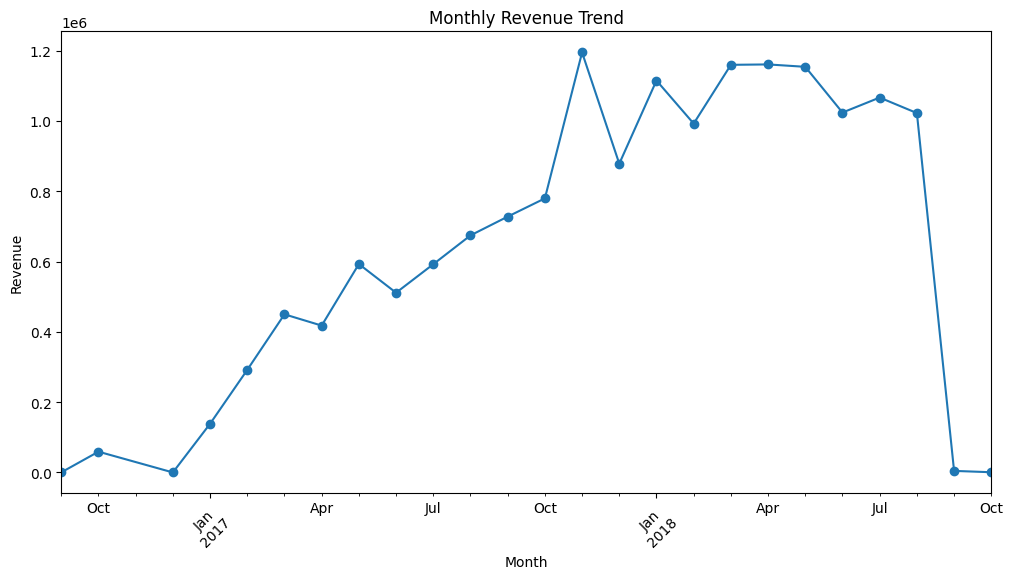

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

monthly_sales.plot(
    marker='o'
)

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

In [57]:
print("Total Revenue =", round(
    df['payment_value'].sum(),2
))

Total Revenue = 16008872.12


In [58]:
print("Average Order Value =",
round(
df['payment_value'].mean(),2
))

Average Order Value = 154.1


Business Insights

1. Revenue increased significantly during 2018.

2. Certain months generated exceptionally high sales.

3. Revenue trend indicates seasonal customer demand.

4. Business should investigate high-performing months for future campaigns.

In [59]:
monthly_sales.sort_values(
    ascending=False
).head(10)

Month
2017-11    1194882.80
2018-04    1160785.48
2018-03    1159652.12
2018-05    1153982.15
2018-01    1115004.18
2018-07    1066540.75
2018-06    1023880.50
2018-08    1022425.32
2018-02     992463.34
2017-12     878401.48
Freq: M, Name: payment_value, dtype: float64

Business Insight:

1. November 2017 generated the highest revenue (1.19 million).
2. Revenue remained consistently strong throughout 2018.
3. The business experienced a significant sales surge during late 2017.
4. Seasonal trends suggest customers spend more during holiday periods.
5. Marketing campaigns during peak months can further increase revenue.

In [60]:
customer_revenue = df.groupby(
    'customer_unique_id'
)['payment_value'].sum()

customer_revenue.head()

customer_unique_id
0000366f3b9a7992bf8c76cfdf3221e2    141.90
0000b849f77a49e4a4ce2b2a4ca5be3f     27.19
0000f46a3911fa3c0805444483337064     86.22
0000f6ccb0745a6a4b88665a16c9f078     43.62
0004aac84e0df4da2b147fca70cf8255    196.89
Name: payment_value, dtype: float64

In [61]:
top_customers = customer_revenue.sort_values(
    ascending=False
).head(10)

top_customers

customer_unique_id
0a0a92112bd4c708ca5fde585afaa872    13664.08
46450c74a0d8c5ca9395da1daac6c120     9553.02
da122df9eeddfedc1dc1f5349a1a690c     7571.63
763c8b1c9c68a0229c42c9fc6f662b93     7274.88
dc4802a71eae9be1dd28f5d788ceb526     6929.31
459bef486812aa25204be022145caa62     6922.21
ff4159b92c40ebe40454e3e6a7c35ed6     6726.66
4007669dec559734d6f53e029e360987     6081.54
5d0a2980b292d049061542014e8960bf     4809.44
eebb5dda148d3893cdaf5b5ca3040ccb     4764.34
Name: payment_value, dtype: float64

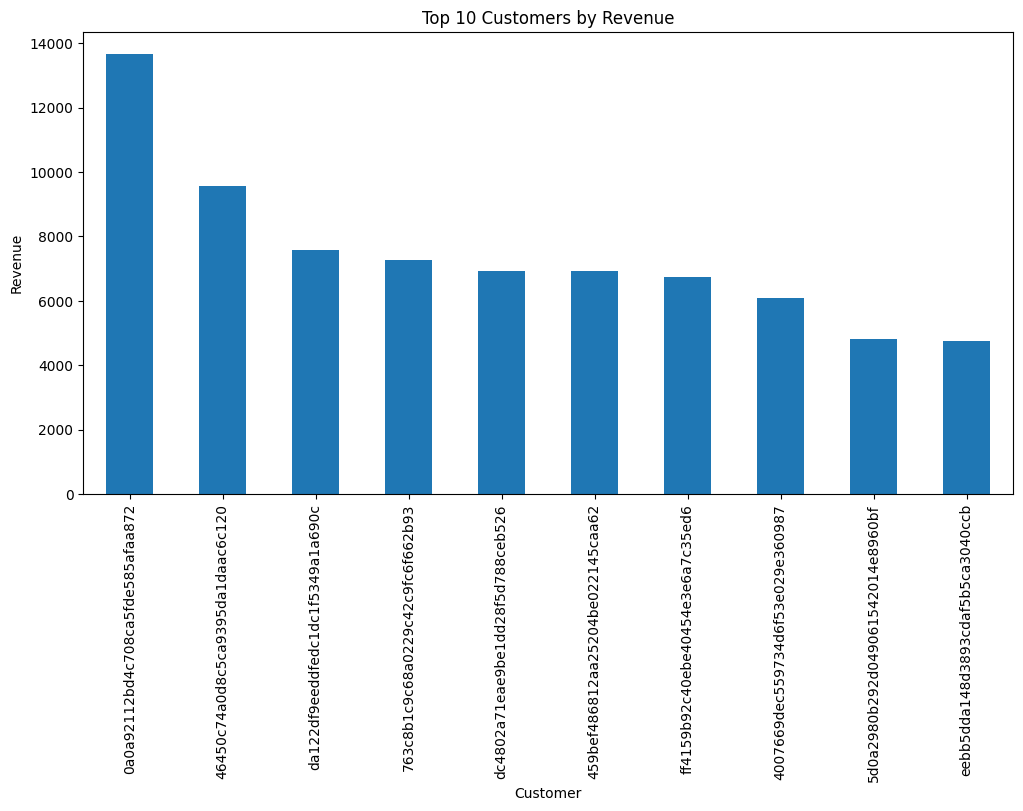

In [62]:
plt.figure(figsize=(12,6))

top_customers.plot(
    kind='bar'
)

plt.title("Top 10 Customers by Revenue")

plt.xlabel("Customer")

plt.ylabel("Revenue")

plt.show()

In [63]:
df['customer_unique_id'].nunique()

96096

In [64]:
customer_revenue.mean()

np.float64(166.5924920912421)

In [65]:
customer_revenue.max()

np.float64(13664.08)

In [66]:
customer_revenue = customer_revenue.sort_values(
    ascending=False
)

cumulative = customer_revenue.cumsum()

revenue_percent = cumulative / customer_revenue.sum()

In [67]:
revenue_percent.head(20)

customer_unique_id
0a0a92112bd4c708ca5fde585afaa872    0.000854
46450c74a0d8c5ca9395da1daac6c120    0.001450
da122df9eeddfedc1dc1f5349a1a690c    0.001923
763c8b1c9c68a0229c42c9fc6f662b93    0.002378
dc4802a71eae9be1dd28f5d788ceb526    0.002810
459bef486812aa25204be022145caa62    0.003243
ff4159b92c40ebe40454e3e6a7c35ed6    0.003663
4007669dec559734d6f53e029e360987    0.004043
5d0a2980b292d049061542014e8960bf    0.004343
eebb5dda148d3893cdaf5b5ca3040ccb    0.004641
48e1ac109decbb87765a3eade6854098    0.004933
c8460e4251689ba205045f3ea17884a1    0.005224
edde2314c6c30e864a128ac95d6b2112    0.005506
a229eba70ec1c2abef51f04987deb7a5    0.005784
edf81e1f3070b9dac83ec83dacdbb9bc    0.006046
fa562ef24d41361e476e748681810e1e    0.006307
ca27f3dac28fb1063faddd424c9d95fa    0.006567
055ec572ac7f3c7bdd04a183830ebe59    0.006820
5e713be0853d8986528d7869a0811d2b    0.007073
58483a1c055dfb600f57c5b867174542    0.007325
Name: payment_value, dtype: float64

In [68]:
df['customer_unique_id'].nunique()

96096

In [69]:
top_customers

customer_unique_id
0a0a92112bd4c708ca5fde585afaa872    13664.08
46450c74a0d8c5ca9395da1daac6c120     9553.02
da122df9eeddfedc1dc1f5349a1a690c     7571.63
763c8b1c9c68a0229c42c9fc6f662b93     7274.88
dc4802a71eae9be1dd28f5d788ceb526     6929.31
459bef486812aa25204be022145caa62     6922.21
ff4159b92c40ebe40454e3e6a7c35ed6     6726.66
4007669dec559734d6f53e029e360987     6081.54
5d0a2980b292d049061542014e8960bf     4809.44
eebb5dda148d3893cdaf5b5ca3040ccb     4764.34
Name: payment_value, dtype: float64

In [70]:
payment_analysis = df.groupby('payment_type')['payment_value'].sum()

payment_analysis.sort_values(ascending=False)

payment_type
credit_card    12542084.19
boleto          2869361.27
voucher          379436.87
debit_card       217989.79
not_defined           0.00
Name: payment_value, dtype: float64

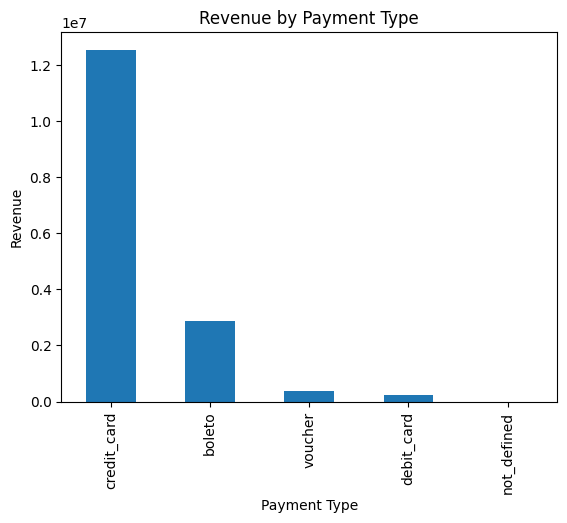

In [71]:
import matplotlib.pyplot as plt

payment_analysis.sort_values(ascending=False).plot(
    kind='bar'
)

plt.title('Revenue by Payment Type')
plt.xlabel('Payment Type')
plt.ylabel('Revenue')
plt.show()

In [72]:
state_revenue = df.groupby('customer_state')['payment_value'].sum()

state_revenue.sort_values(
    ascending=False
).head(10)

customer_state
SP    5998226.96
RJ    2144379.69
MG    1872257.26
RS     890898.54
PR     811156.38
SC     623086.43
BA     616645.82
DF     355141.08
GO     350092.31
ES     325967.55
Name: payment_value, dtype: float64

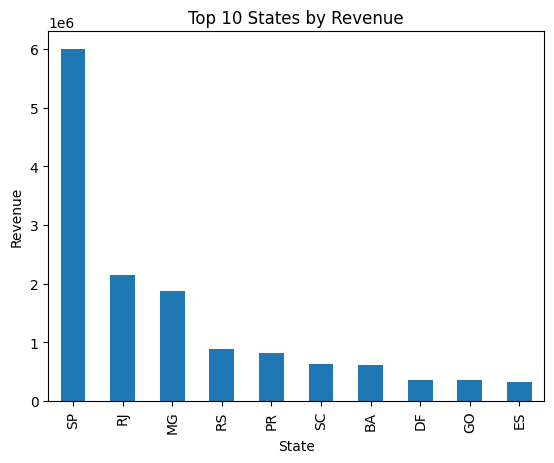

In [73]:
import matplotlib.pyplot as plt

state_revenue.sort_values(
    ascending=False
).head(10).plot(kind='bar')

plt.title('Top 10 States by Revenue')
plt.xlabel('State')
plt.ylabel('Revenue')
plt.show()

In [75]:
df.shape

(103887, 17)

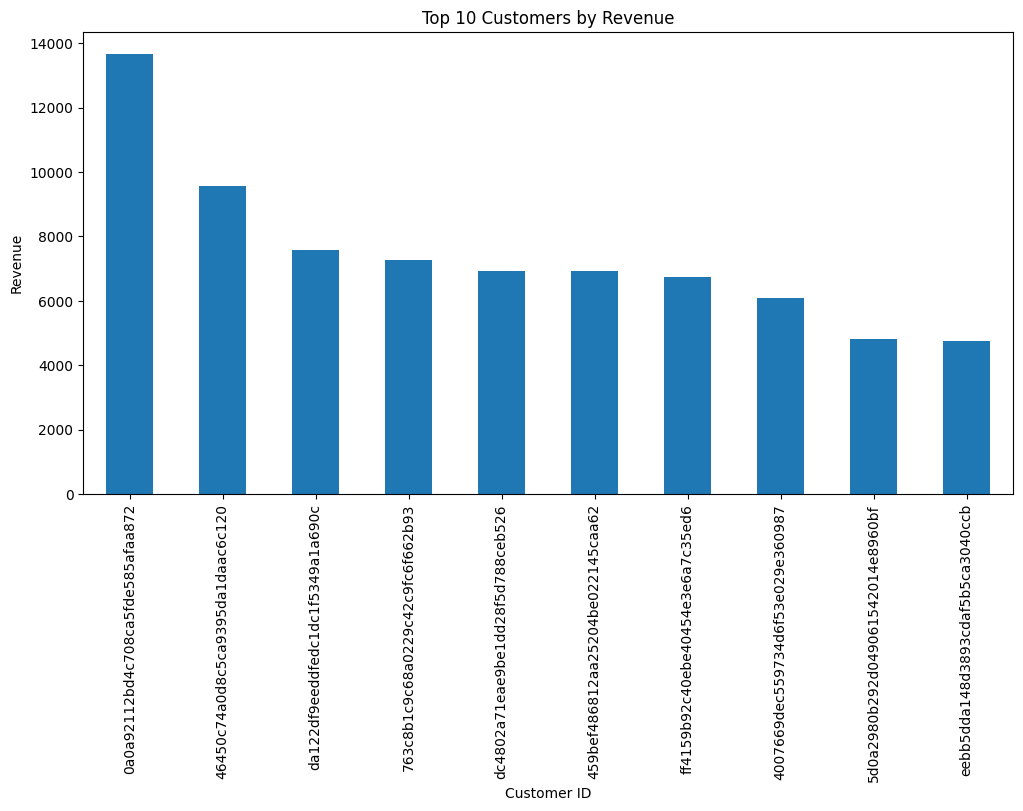

In [76]:
top_customers = customer_revenue.sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

top_customers.plot(kind='bar')

plt.title('Top 10 Customers by Revenue')
plt.xlabel('Customer ID')
plt.ylabel('Revenue')

plt.show()

• Revenue is concentrated among a small group of customers.
• The highest spending customer contributed over 13,000 in revenue.
• Loyalty programs should focus on these customers.

In [81]:
monthly_orders = df.groupby(
    'Month'
)['order_id'].count()

monthly_orders

Month
2016-09       4
2016-10     342
2016-12       1
2017-01     850
2017-02    1886
2017-03    2837
2017-04    2571
2017-05    3944
2017-06    3436
2017-07    4317
2017-08    4550
2017-09    4516
2017-10    4860
2017-11    7863
2017-12    5895
2018-01    7563
2018-02    6952
2018-03    7512
2018-04    7209
2018-05    7135
2018-06    6419
2018-07    6507
2018-08    6698
2018-09      16
2018-10       4
Freq: M, Name: order_id, dtype: int64

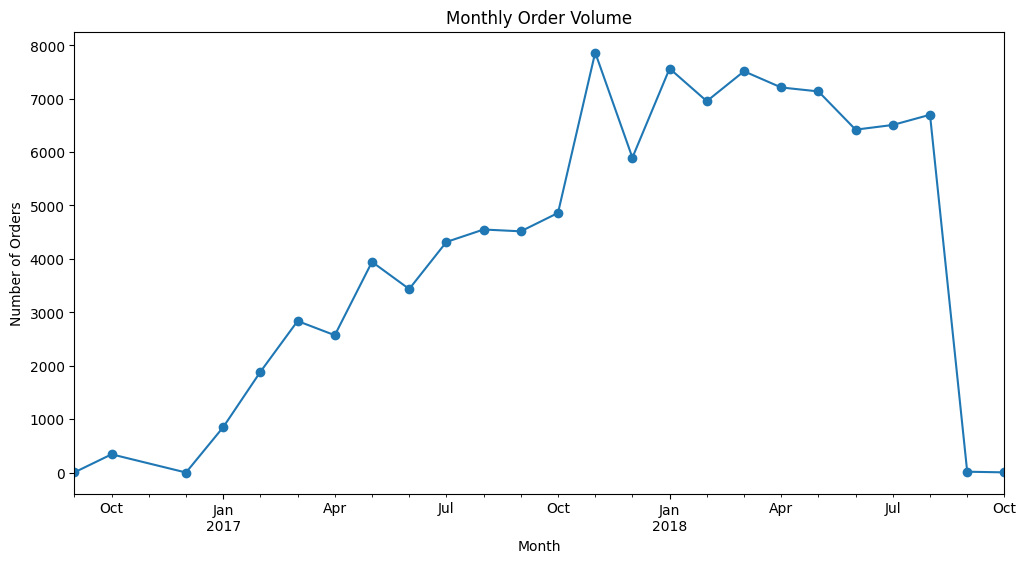

In [82]:
plt.figure(figsize=(12,6))

monthly_orders.plot(
    marker='o'
)

plt.title('Monthly Order Volume')
plt.xlabel('Month')
plt.ylabel('Number of Orders')

plt.show()

• Order volume increased steadily throughout 2018.
• High order volume months generally correspond to high revenue months.

In [83]:
city_revenue = df.groupby(
    'customer_city'
)['payment_value'].sum()

top_cities = city_revenue.sort_values(
    ascending=False
).head(10)

top_cities

customer_city
sao paulo         2203373.09
rio de janeiro    1161927.36
belo horizonte     421765.12
brasilia           354216.78
curitiba           247392.48
porto alegre       224731.42
salvador           218071.50
campinas           216248.43
guarulhos          165121.99
niteroi            139996.99
Name: payment_value, dtype: float64

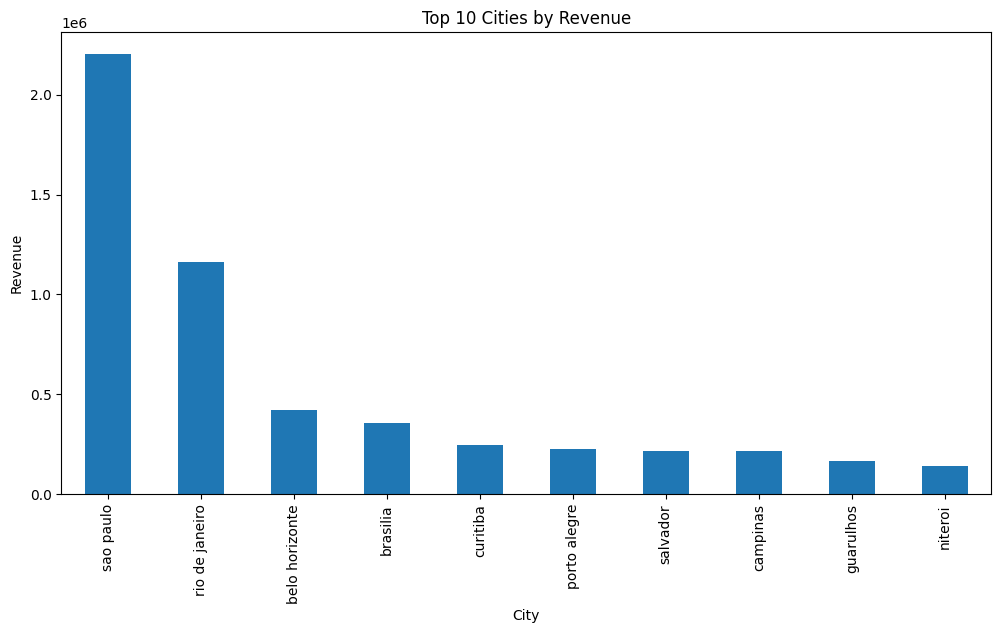

In [84]:
plt.figure(figsize=(12,6))

top_cities.plot(kind='bar')

plt.title('Top 10 Cities by Revenue')
plt.xlabel('City')
plt.ylabel('Revenue')

plt.show()

In [85]:
status_analysis = df['order_status'].value_counts()

status_analysis

order_status
delivered      100757
shipped          1166
canceled          664
unavailable       649
invoiced          325
processing        319
created             5
approved            2
Name: count, dtype: int64

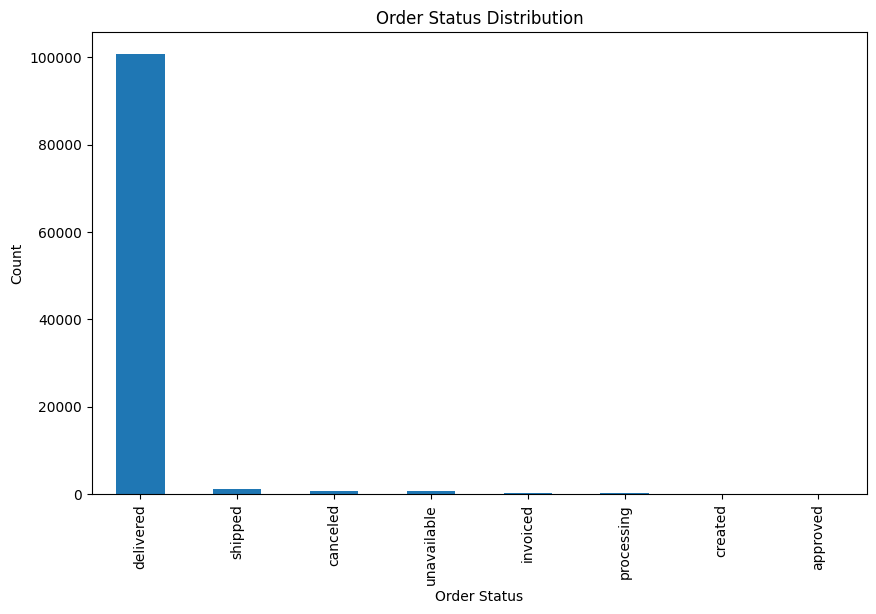

In [86]:
status_analysis.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Order Status Distribution')
plt.xlabel('Order Status')
plt.ylabel('Count')

plt.show()

• Most orders are successfully delivered.
• Cancellation and unavailable orders are minimal.

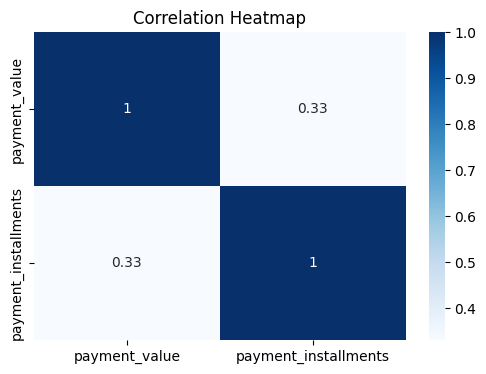

In [87]:
import seaborn as sns

numeric_cols = [
    'payment_value',
    'payment_installments'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,
    cmap='Blues'
)

plt.title('Correlation Heatmap')

plt.show()

In [89]:
customer_revenue = df.groupby(
    'customer_unique_id'
)['payment_value'].sum()

def segment_customer(revenue):
    if revenue >= 183.53:
        return 'High Value'
    elif revenue >= 108:
        return 'Medium Value'
    else:
        return 'Low Value'

customer_segments = customer_revenue.apply(segment_customer)

customer_segments.value_counts()

payment_value
Low Value       48030
Medium Value    24037
High Value      24029
Name: count, dtype: int64

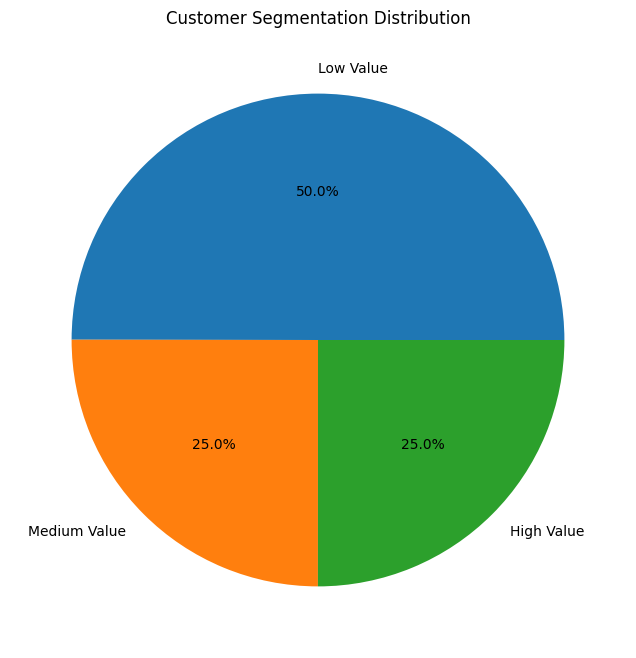

In [90]:
import matplotlib.pyplot as plt

segment_counts = customer_segments.value_counts()

plt.figure(figsize=(8,8))

segment_counts.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Customer Segmentation Distribution')
plt.ylabel('')

plt.show()

# Business Recommendations

1. Increase marketing investment in São Paulo, Rio de Janeiro, and Minas Gerais.

2. Introduce loyalty rewards for High Value customers.

3. Develop retention campaigns to encourage repeat purchases.

4. Promote alternative payment methods while maintaining a seamless credit card experience.

5. Expand operations in high-performing cities to maximize revenue growth.

# Conclusion

This project analyzed customer behavior and sales performance using the Olist E-commerce dataset.

Key Findings:

• Total Revenue exceeded 16 Million.
• November 2017 recorded the highest monthly revenue.
• Credit Card was the most preferred payment method.
• São Paulo generated the highest revenue among all states.
• High Value customers contributed significantly to overall sales.

These insights can help businesses improve customer retention, optimize marketing strategies, and increase profitability.